In [1]:
using IonSim
using QuantumOptics
using PyPlot
using LinearAlgebra

In [2]:
function laguerre(n::Int, x::Float64)
    if n == 0 return 1.0 end
    if n == 1 return 1.0 - x end
    L_prev2 = 1.0
    L_prev1 = 1.0 - x
    L_curr = 0.0
    for k in 1:(n-1)
        L_curr = ((2k + 1 - x) * L_prev1 - k * L_prev2) / (k + 1)
        L_prev2 = L_prev1
        L_prev1 = L_curr
    end
    return L_curr
end

laguerre (generic function with 1 method)

In [3]:
function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end

calculate_qcrb (generic function with 1 method)

In [4]:
function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(20)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end

plot_wigner (generic function with 1 method)

In [5]:
function SDF_apply_with_alpha(laser_intensity = 1e4, angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0, n_th_set = 10000.0, gamma_0_set = 1e-2)

    # ---------------------------------------------------------
    # 1. Common Trap Initialization
    # ---------------------------------------------------------
    trap_freq = 19e5 
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] 
    mode_z.N = 50
    mode_z.shape = [51]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    B_field = 1e-13
    
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    mode = zmodes(trap_pre)[1]

    ψ_ion = normalize(ion["g"])
    ψ_mode = fockstate(mode, fock_state_n)
    
    ψ_initial = initial_state !== nothing ? initial_state : (ψ_ion ⊗ ψ_mode)

    # ---------------------------------------------------------
    # 2. Physics Calculation
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π

    # ---------------------------------------------------------
    # 3. SEQUENCE EXECUTION
    # ---------------------------------------------------------
    if cat_state
        # =========================================================
        # PERFECT OPERATOR MATH: Alpha Readout (No readout noise)
        # =========================================================
        alpha_complex = target_alpha * exp(1im * angle)
        g = ion["g"]
        e = ion["e"]
        
        x_plus = normalize(g + e)
        x_minus = normalize(g - e)
        
        P_plus = x_plus ⊗ dagger(x_plus)
        P_minus = x_minus ⊗ dagger(x_minus)
        
        D_plus = IonSim.displace(mode, alpha_complex)
        D_minus = IonSim.displace(mode, -alpha_complex)
        
        U_SDF = (P_plus ⊗ D_plus) + (P_minus ⊗ D_minus)
        
        if isa(ψ_initial, Operator)
            return U_SDF * ψ_initial * dagger(U_SDF)
        else
            return U_SDF * ψ_initial
        end
        
    else
        # =========================================================
        # CONTINUOUS LINDBLAD DISPLACEMENT: Beta Signal (With Noise)
        # =========================================================
        I_spin = identityoperator(ion["g"].basis)  
        n_th = n_th_set           
        gamma_0 = gamma_0_set  
    
        gamma_plus_us = (gamma_0 * n_th) * 1e-6 
        gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 

        temp_fock_basis = FockBasis(mode.N) 
        a_op = DenseOperator(mode, mode, QuantumOptics.destroy(temp_fock_basis).data)
        at_op = DenseOperator(mode, mode, QuantumOptics.create(temp_fock_basis).data)

        # CRITICAL FIX: Lock the simulation time to the beta=1.0 baseline.
        # This guarantees identical ODE grid steps for finite difference.
        baseline_beta = 1.0 
        target_time_s = (2 * baseline_beta) / (eta * Omega_eff)
        target_time_us = target_time_s * 1e6

        # The target_alpha (beta + d_beta) now scales the Hamiltonian amplitude!
        H_m = (1im * target_alpha / target_time_us) * (exp(1im * angle) * at_op - exp(-1im * angle) * a_op)
        H_sys = I_spin ⊗ H_m

        a_sys = I_spin ⊗ a_op
        at_sys = I_spin ⊗ at_op

        J_cool = sqrt(gamma_minus_us) * a_sys
        J_heat = sqrt(gamma_plus_us) * at_sys
        J_ops = [J_cool, J_heat]
        J_ops_dag = dagger.(J_ops)

        function f_dyn(time_t, rho_state)
            return (H_sys, J_ops, J_ops_dag)
        end

        rho_initial = isa(ψ_initial, Ket) ? dm(ψ_initial) : ψ_initial
        
        # We only need the start and end points for the solver now
        tspan_sdf = [0.0, target_time_us]

        println("Simulating pure continuous Beta displacement with Lindblad noise...")
        # Added strict tolerances to completely eliminate numerical ODE phase drift
        _, sol_beta = timeevolution.master_dynamic(tspan_sdf, rho_initial, f_dyn, reltol=1e-10, abstol=1e-12)

        return sol_beta[end]
    end
end

SDF_apply_with_alpha (generic function with 9 methods)

In [11]:

function get_qcrb_coordinates(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    
    beta_signal = 1.0
    d_beta = 1e-4 
    
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    sim_mode = zmodes(trap_pre)[1]
    sim_mode.N = 50
    sim_mode.shape = [51]
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    
    t_sig_s = (2 * beta_signal) / (eta * Omega_eff)
    t_sig_us = t_sig_s * 1e6
    
    println("==================================================")
    println(" EXACT TIME CALCULATION")
    println("==================================================")
    println(" Signal Magnitude (β): ", beta_signal)
    println(" Exposure Time (t)   : ", round(t_sig_us, digits=2), " μs")
    println(" Base Gamma Rate     : ", gamma_0)
    println(" Thermal Phonons (n) : ", n_th_set)
    println("==================================================")

    b_fock = FockBasis(50) 
    vac_qo = fockstate(b_fock, n_fock)
    
    if r_squeeze > 0.0
        squeeze_op = squeeze(b_fock, r_squeeze * exp(1im * 0.0))
        initial_m_qo = squeeze_op * vac_qo
    else
        initial_m_qo = vac_qo
    end
    
    initial_m_sim = Ket(sim_mode, initial_m_qo.data)
    initial_sys = normalize(ion["g"]) ⊗ initial_m_sim

    println("\nRunning master equation for Base β Signal...")
    # Passed gamma_0 into the generator
    noisy_beta_state = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal, false, initial_sys, n_fock, n_th_set, gamma_0)
    
    println("\nRunning master equation for Perturbed β Signal (+ d_beta)...")
    # Passed gamma_0 into the generator
    noisy_beta_state_pert = SDF_apply_with_alpha(laser_intensity, 0.0, beta_signal + d_beta, false, initial_sys, n_fock, n_th_set, gamma_0)

    alphas = collect(0.1:0.1:1.6)
    sim_qcrbs = Float64[]
    theory_thermal_qcrbs = Float64[]
    theory_closed_qcrbs = Float64[]
    theory_nolaser_qcrbs = Float64[]

    Gamma_t = (gamma_0 * 1e-6) * t_sig_us

    println("\nSweeping α readout (generating coordinates)...")
    for a in alphas
        # Passed gamma_0 into the readout
        state_a_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state, n_fock, n_th_set, gamma_0)
        state_a_pert_full = SDF_apply_with_alpha(laser_intensity, pi/2, a, true, noisy_beta_state_pert, n_fock, n_th_set, gamma_0)

        rho_spin_a = ptrace(state_a_full, 2)
        rho_spin_a_pert = ptrace(state_a_pert_full, 2)
        
        _, qcrb_sim = calculate_qcrb(rho_spin_a, rho_spin_a_pert, d_beta)
        push!(sim_qcrbs, qcrb_sim)

        # --- REVISED CONTINUOUS DRIVE THEORY ---
        # 1. Variance envelope (exponent) remains unchanged
        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        # 2. Laguerre term remains unchanged
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        
        # 3. Continuous signal integration (safeguarded against Gamma_t = 0)
        continuous_signal_factor = Gamma_t > 1e-10 ? (2.0 / Gamma_t) * (1.0 - exp(-Gamma_t / 2.0)) : 1.0
        
        # 4. Denominator applies the continuous signal factor instead of instantaneous exp(-Gamma_t)
        denominator_open = 16 * a^2 * (continuous_signal_factor^2) * (L_val_open^2)
        
        push!(theory_thermal_qcrbs, numerator_open / denominator_open)
        # ---------------------------------------

        exp_term_closed = 4 * a^2 * exp(-2*r_squeeze)
        numerator_closed = exp(exp_term_closed)
        
        L_val_closed = laguerre(n_fock, 4 * a^2 * exp(-2*r_squeeze))
        denominator_closed = 16 * a^2 * (L_val_closed^2)
        
        push!(theory_closed_qcrbs, numerator_closed / denominator_closed)

        thermal_heating_factor = (2 * n_th_set) + 1.0
        exp_term_open = 4 * a^2 * (thermal_heating_factor * (1 - exp(-Gamma_t)) + exp(-Gamma_t - 2*r_squeeze))
        numerator_open = exp(exp_term_open)
        
        L_val_open = laguerre(n_fock, 4 * a^2 * exp(-Gamma_t - 2*r_squeeze))
        denominator_open = 16 * a^2 * exp(-Gamma_t) * (L_val_open^2)
        
        push!(theory_nolaser_qcrbs, numerator_open / denominator_open)
    end

    return alphas, sim_qcrbs, theory_thermal_qcrbs, theory_closed_qcrbs, theory_nolaser_qcrbs
end

get_qcrb_coordinates (generic function with 6 methods)

In [16]:
function plot_qcrb_results(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    x_alpha, y_sim, y_theory_open, y_theory_closed, y_nolaser_drift = get_qcrb_coordinates(n_fock, r_squeeze, laser_intensity, gamma_0, n_th_set)

    fig = figure(figsize=(8, 6))
    
    plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = $(n_th_set))")
    plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")
    plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Eq. 33: Closed System)")
    plot(x_alpha, y_nolaser_drift, "g-.", linewidth=2, label="Theory (Eq. 80: No Laser Drift)")

    yscale("log")
    xlabel("Readout Displacement [α]", fontsize=12)
    ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
    title("Fock = $(n_fock), r = $(r_squeeze), Signal Laser I = $(laser_intensity), gamma = $(gamma_0), n_th = $(n_th_set)", fontsize=14)
    
    legend(fontsize=11)
    grid(alpha=0.4)
    
    display(fig)
end

plot_qcrb_results (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


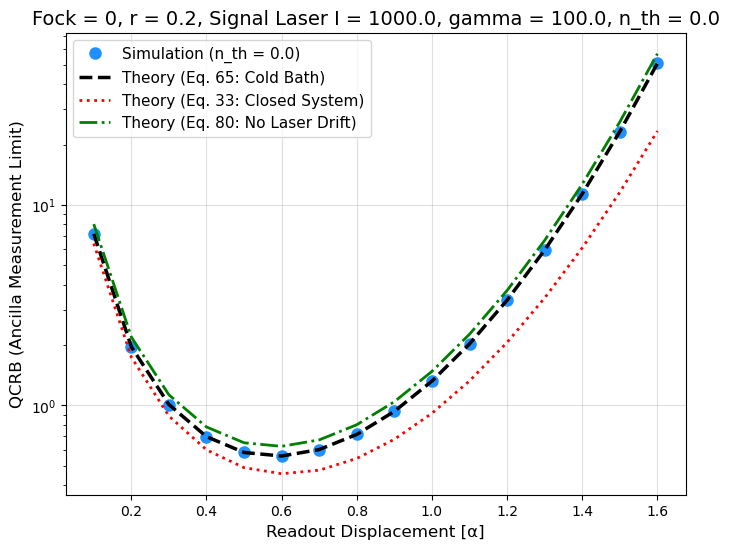

In [17]:
plot_qcrb_results(0, 0.2, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 1000.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


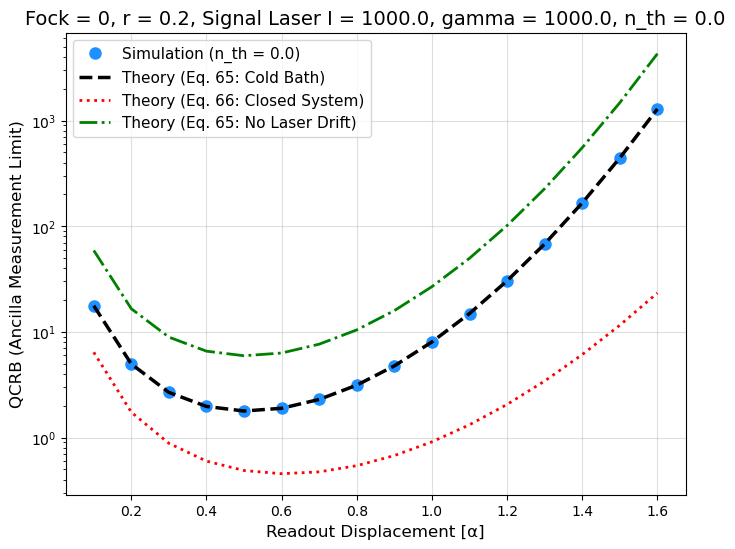

In [14]:
plot_qcrb_results(0, 0.2, 1e3, 1e3, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 22066.74 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


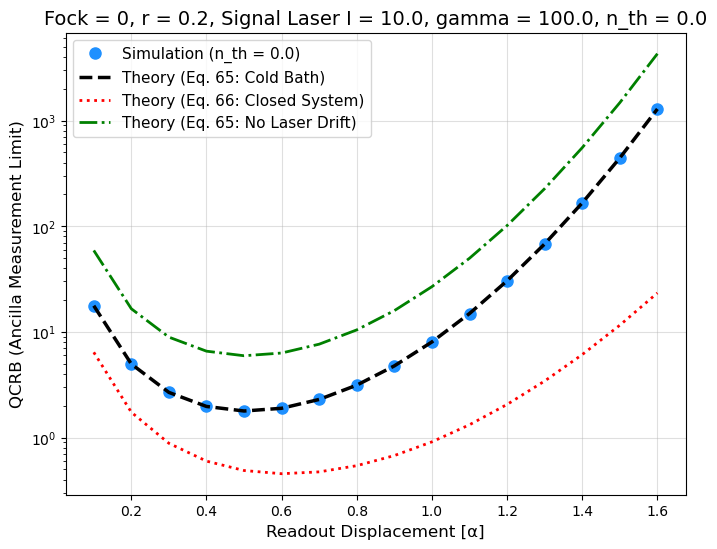

In [15]:
plot_qcrb_results(0, 0.2, 1e1, 1e2, 0.0)

Include spin Motional coupling rate during the plot qcrb results based on the laser intensity and the beta we want to reach. 

Approximately we can think of the coupling as speed to reach beta so the relation is $\beta = g * t$

We defined this in the plot as $g = \frac{\eta \Omega}{2}$ and $\alpha(t) = g t = \frac{\eta \Omega}{2} t$

And now we can easily compare $\Gamma vs g$ since their units are b oth in rad/s

If $g>> \Gamma$ we are in the strong metrology regime and no significant drfit between open qcrb without laser drfit and with laser drift. If $\Gamma >= g$ we can see that the noise dominates and cuases the two analytical function to separate largely.

In [19]:
function plot_qcrb_results(n_fock::Int=0, r_squeeze::Float64=0.0, laser_intensity::Float64=1e3, gamma_0::Float64=1e-2, n_th_set::Float64=1000.0)
    x_alpha, y_sim, y_theory_open, y_theory_closed, y_nolaser_drift = get_qcrb_coordinates(n_fock, r_squeeze, laser_intensity, gamma_0, n_th_set)

    # --- Recompute coupling rate g for the title ---
    trap_freq = 19e5 
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
    B_field = 1e-13
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)
    
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_z = (2 * π / transition_λ) / sqrt(2)
    eta = k_z * z_zpf

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    
    # Calculate coupling rate g (rad/s) and round for the title
    g_coupling = (eta * Omega_eff_Hz * 2 * π) / 2.0
    g_display = round(g_coupling, digits=2)
    # -----------------------------------------------

    fig = figure(figsize=(8, 6))
    
    plot(x_alpha, y_sim, "o", markersize=8, color="dodgerblue", label="Simulation (n_th = $(n_th_set))")
    plot(x_alpha, y_theory_open, "k--", linewidth=2.5, label="Theory (Eq. 65: Cold Bath)")
    plot(x_alpha, y_theory_closed, "r:", linewidth=2, label="Theory (Eq. 33: Closed System)")
    plot(x_alpha, y_nolaser_drift, "g-.", linewidth=2, label="Theory (Eq. 80: No Laser Drift)")

    yscale("log")
    xlabel("Readout Displacement [α]", fontsize=12)
    ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
    
    # Updated title: dropped fontsize slightly to accommodate the longer string
    title("Fock = $(n_fock), r = $(r_squeeze), I = $(laser_intensity) (g = $(g_display)), gamma = $(gamma_0), n_th = $(n_th_set)", fontsize=11)
    
    legend(fontsize=11)
    grid(alpha=0.4)
    
    display(fig)
end

plot_qcrb_results (generic function with 6 methods)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 22066.74 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


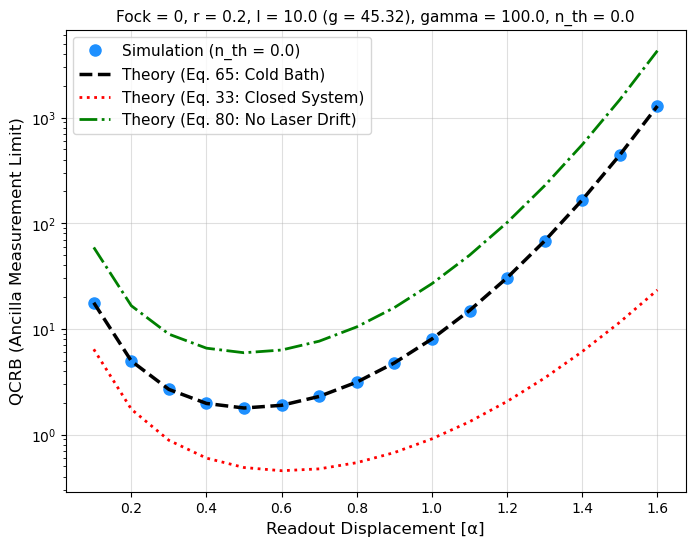

In [20]:
plot_qcrb_results(0, 0.2, 1e1, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


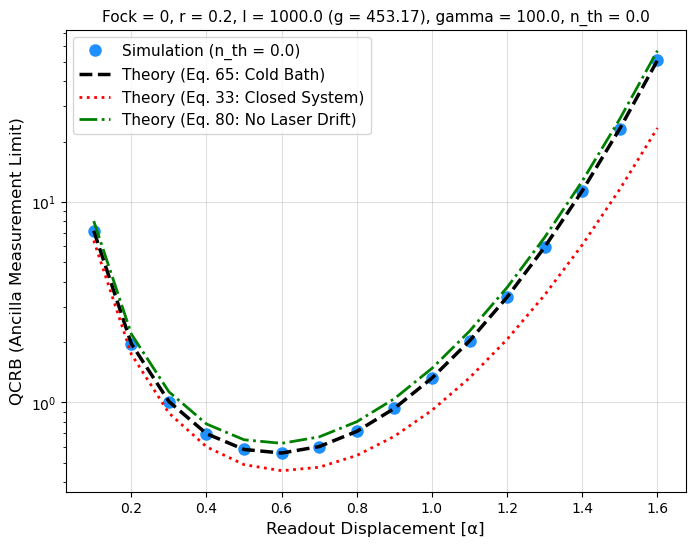

In [21]:
plot_qcrb_results(0, 0.2, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


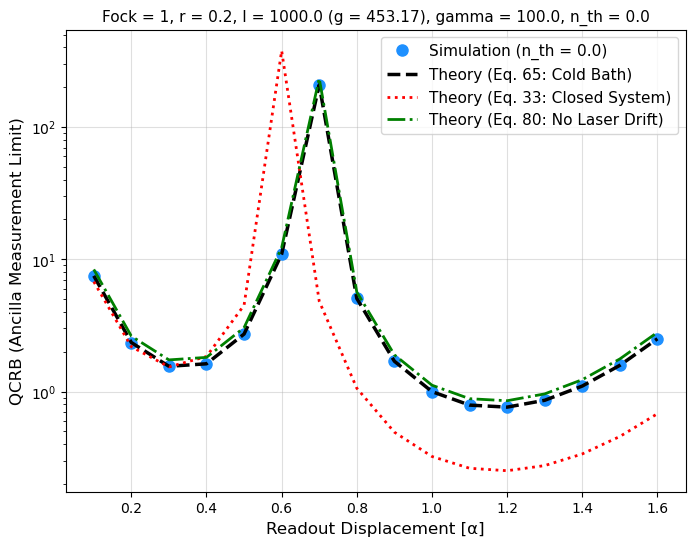

In [22]:
plot_qcrb_results(1, 0.2, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 2206.67 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


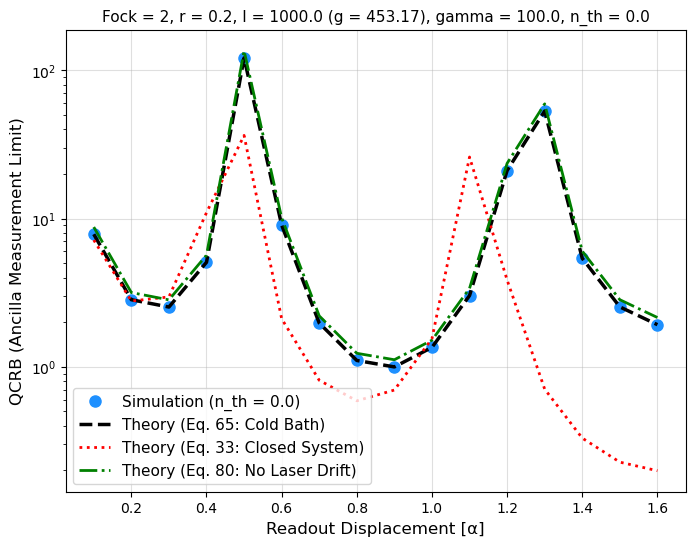

In [23]:
plot_qcrb_results(2, 0.2, 1e3, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 6978.12 μs
 Base Gamma Rate     : 100.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


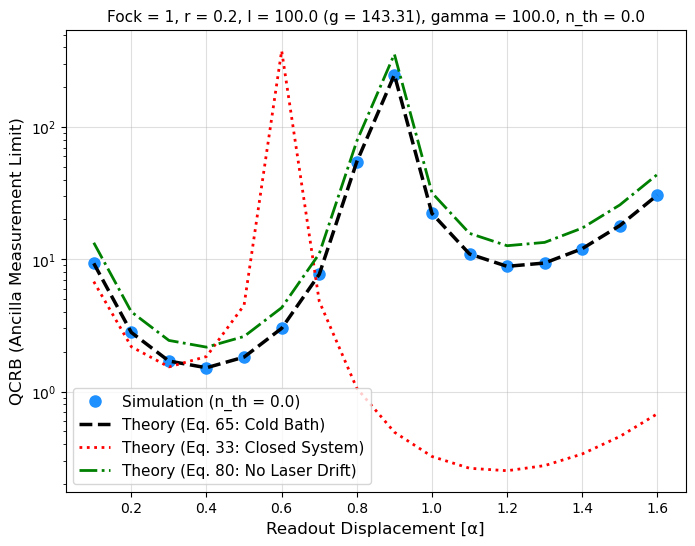

In [24]:
plot_qcrb_results(1, 0.2, 1e2, 1e2, 0.0)

 EXACT TIME CALCULATION
 Signal Magnitude (β): 1.0
 Exposure Time (t)   : 6978.12 μs
 Base Gamma Rate     : 10000.0
 Thermal Phonons (n) : 0.0

Running master equation for Base β Signal...
Simulating pure continuous Beta displacement with Lindblad noise...

Running master equation for Perturbed β Signal (+ d_beta)...
Simulating pure continuous Beta displacement with Lindblad noise...

Sweeping α readout (generating coordinates)...


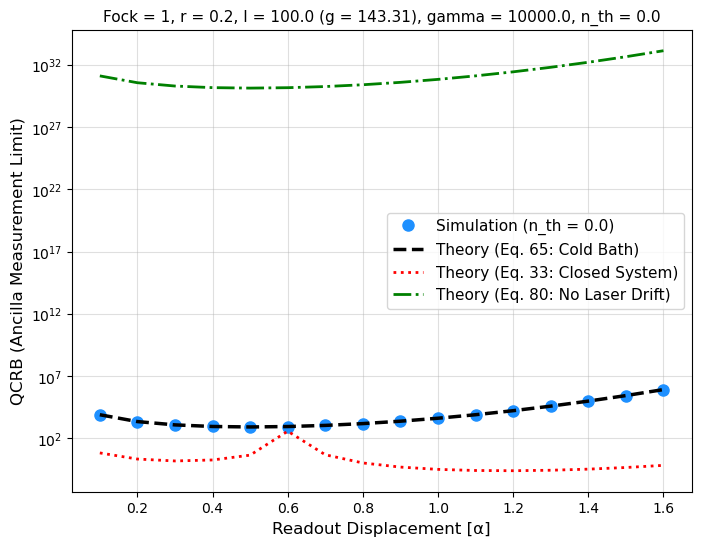

In [25]:
plot_qcrb_results(1, 0.2, 1e2, 1e4, 0.0)